In [64]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

In [73]:
class AgentState(TypedDict):
    player_name: str
    guesses : List[int]
    attempts: int
    lower_bound :int
    upper_bound :int
    target_number: int
    Hint: str

In [74]:
def setup(state: AgentState) -> AgentState:
    state['attempts'] = 0
    state['target_number'] = random.randint(1,20)
    state['player_name'] = f"Hey, {state['player_name']} The game has begun. I'm thinking of a number between 1 and 20."
    return state

In [75]:
def guess(state: AgentState) -> AgentState:
    possible_guesses = [i for i in range (state['lower_bound'] , state['upper_bound']+1) if i not in state['guesses']]
    if possible_guesses:
        guess = random.choice(possible_guesses)
    else:
        guess = random.randint(state['lower_bound'], state['upper_bound'])
    state['guesses'].append(guess)
    state['attempts'] +=1
    print(f"Attempt {state['attempts']}: Guessing {guess} (Current range: {state['lower_bound']}-{state['upper_bound']})")
    return state

In [88]:
def hint_node(state: AgentState) -> AgentState:
    latest_guess = state['guesses'][-1]
    if latest_guess > state['target_number']:
        state['Hint'] = f"Hint: The number {latest_guess} is too high. Try lower!"
        state['upper_bound'] = latest_guess
        print(state['Hint'])
    elif latest_guess < state['target_number']:
        state['Hint'] = f"Hint: The number {latest_guess} is too low. Try higher!"
        state['lower_bound'] = latest_guess
        print(state['Hint'])
    else:
        state['Hint'] = f"Success! Correct! You found the number {state['target_number']} in {state['attempts']} attempts."
        print(state['Hint'])
    return state

In [89]:
def continue_looping(state: AgentState) -> AgentState:
    """A node to determine if the graph should continue or not"""

    latest_guess = state['guesses'][-1]
    if latest_guess == state['target_number']:
        print(f"Game over!! Number Found ")
        return "END"
    elif state['attempts'] >= 7 :
        print (f"GAME OVER: Maximum attempts reached! The number was {state['target_number']}")
        return "END"
    else:
        print(f"CONTINUING: {state['attempts']}/7 attempts used")
        return "CONTINUE"

In [90]:
graph = StateGraph(AgentState)
graph.add_node("setup", setup)
graph.add_node("guess", guess)
graph.add_node("hint_node", hint_node)
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint_node")
graph.add_conditional_edges(
    "hint_node",
    continue_looping,
    {
        "CONTINUE":"guess",
        "END":END
    }
)
graph.add_edge(START, "setup")
app = graph.compile()

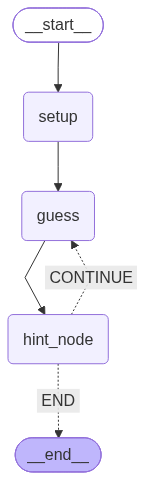

In [91]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [92]:
result = app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})

Attempt 1: Guessing 17 (Current range: 1-20)
Hint: The number 17 is too high. Try lower!
CONTINUING: 1/7 attempts used
Attempt 2: Guessing 7 (Current range: 1-17)
Hint: The number 7 is too low. Try higher!
CONTINUING: 2/7 attempts used
Attempt 3: Guessing 16 (Current range: 7-17)
Hint: The number 16 is too high. Try lower!
CONTINUING: 3/7 attempts used
Attempt 4: Guessing 9 (Current range: 7-16)
Hint: The number 9 is too low. Try higher!
CONTINUING: 4/7 attempts used
Attempt 5: Guessing 15 (Current range: 9-16)
Hint: The number 15 is too high. Try lower!
CONTINUING: 5/7 attempts used
Attempt 6: Guessing 11 (Current range: 9-15)
Success! Correct! You found the number 11 in 6 attempts.
Game over!! Number Found 
